<h1 style="text-align: center; color: blue;">Predicting Loan Default Risk Using Machine Learning</h1>

<h2 style="text-align: center;">An End-to-End Credit Risk Analytics Project</h2>
<hr>

**Author**: ELIJAH APPIAH

**Type of Project**: Machine Learning / Explainable AI

**Dataset**: Home Credit Default Risk (Access on Kaggle: <https://www.kaggle.com/competitions/home-credit-default-risk/data>)

<hr>

## Business Problem

Financial institutions face huge losses when borrowers default on loans. The traditional credit scoring systems often exclude individuals with insufficient credit histories and this tends to limit financial inclusion as a whole. This project aims to use machine learning to predict the probability of loan default using demographic, financial, behavioral, and historical credit information.

The objective therefore is to build an interpretable and production-oriented credit risk prediction pipeline capable of assisiting lenders to identify high-risk borrowers, reduce non-performing loans, improve their lending decisions, and promoting financial inclusion.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

import shap
import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

Private sharing of dataset is not allowed due to their privacy policy and it is important to note that this dataset is one of the Kaggle competitions hosted on their website. Therefore, I will encourgae you to get the data by yourself from source using the link below:

<https://www.kaggle.com/competitions/home-credit-default-risk/data>

Download the `application_train.csv` and `application_test.csv` from the data directory on the website.

In [46]:
train_df = pd.read_csv('credit_data/application_train.csv')
test_df = pd.read_csv('credit_data/application_test.csv')

print(train_df.shape)
print(test_df.shape)
print(f'The training data has {train_df.shape[0]} rows and {train_df.shape[1]} columns.')
print(f'The test data has {test_df.shape[0]} rows and {test_df.shape[1]} columns.')

(307511, 122)
(48744, 121)
The training data has 307511 rows and 122 columns.
The test data has 48744 rows and 121 columns.


## Exploratory Data Analysis (EDA)

In [4]:
train_df.head()   # view first five observations of training data

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
test_df.head()    # view first five observations of test data

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
print(train_df.info())
print("\n")
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 125 entries, SK_ID_CURR to EMPLOYMENT_AGE_RATIO
dtypes: float64(68), int64(57)
memory usage: 293.3 MB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 121 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), object(16)
memory usage: 45.0+ MB
None


## Check for Missing Values

In [17]:
# Check missing values
missing_values = train_df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

missing_df.head(20)    # first 20 features with proportion of missing observations

,Missing Values,Percentage
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
FLOORSMIN_MEDI,208642,67.848630


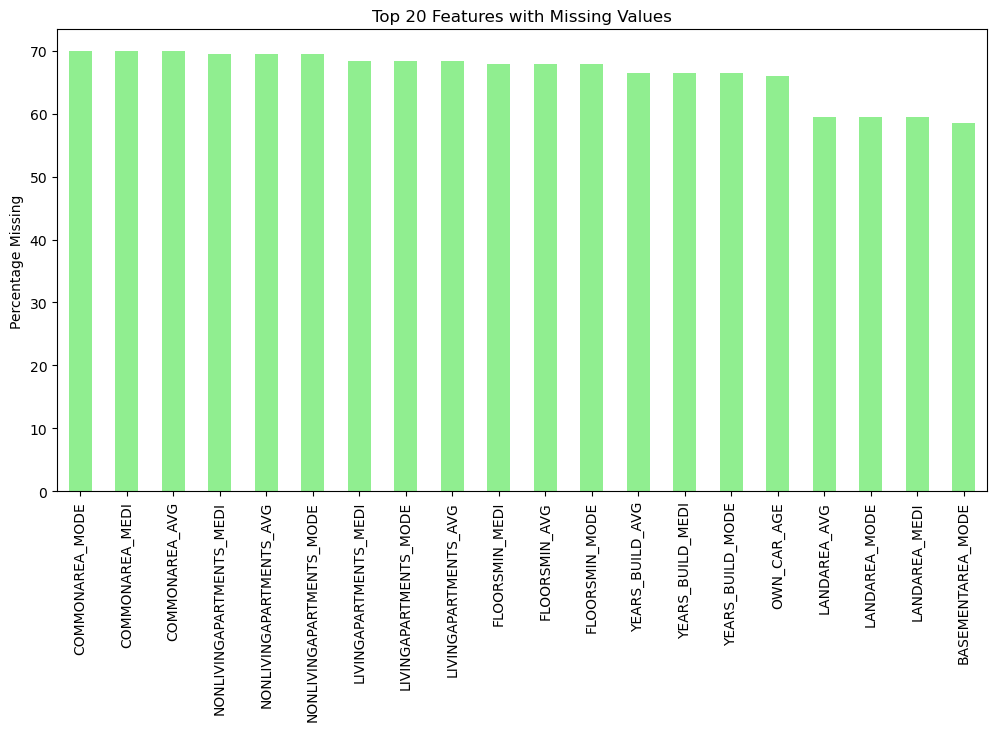

In [58]:
# Visualize the first 20 features and their proportion of missing values
plt.figure(figsize=(12,6))
missing_percent.head(20).plot(kind='bar', color='lightgreen')
plt.title('Top 20 Features with Missing Values')
plt.ylabel('Percentage Missing');

## Check and Visualize Class Imbalance

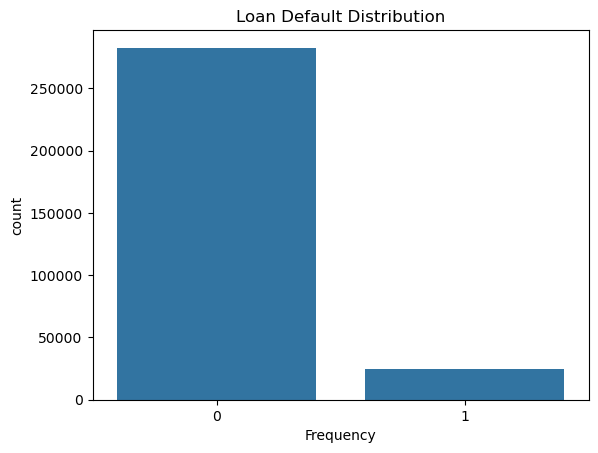

In [59]:
# Class Imbalance
sns.countplot(x='TARGET', data=train_df)
plt.xlabel('Frequency')
plt.title('Loan Default Distribution');

## Correlation between Features

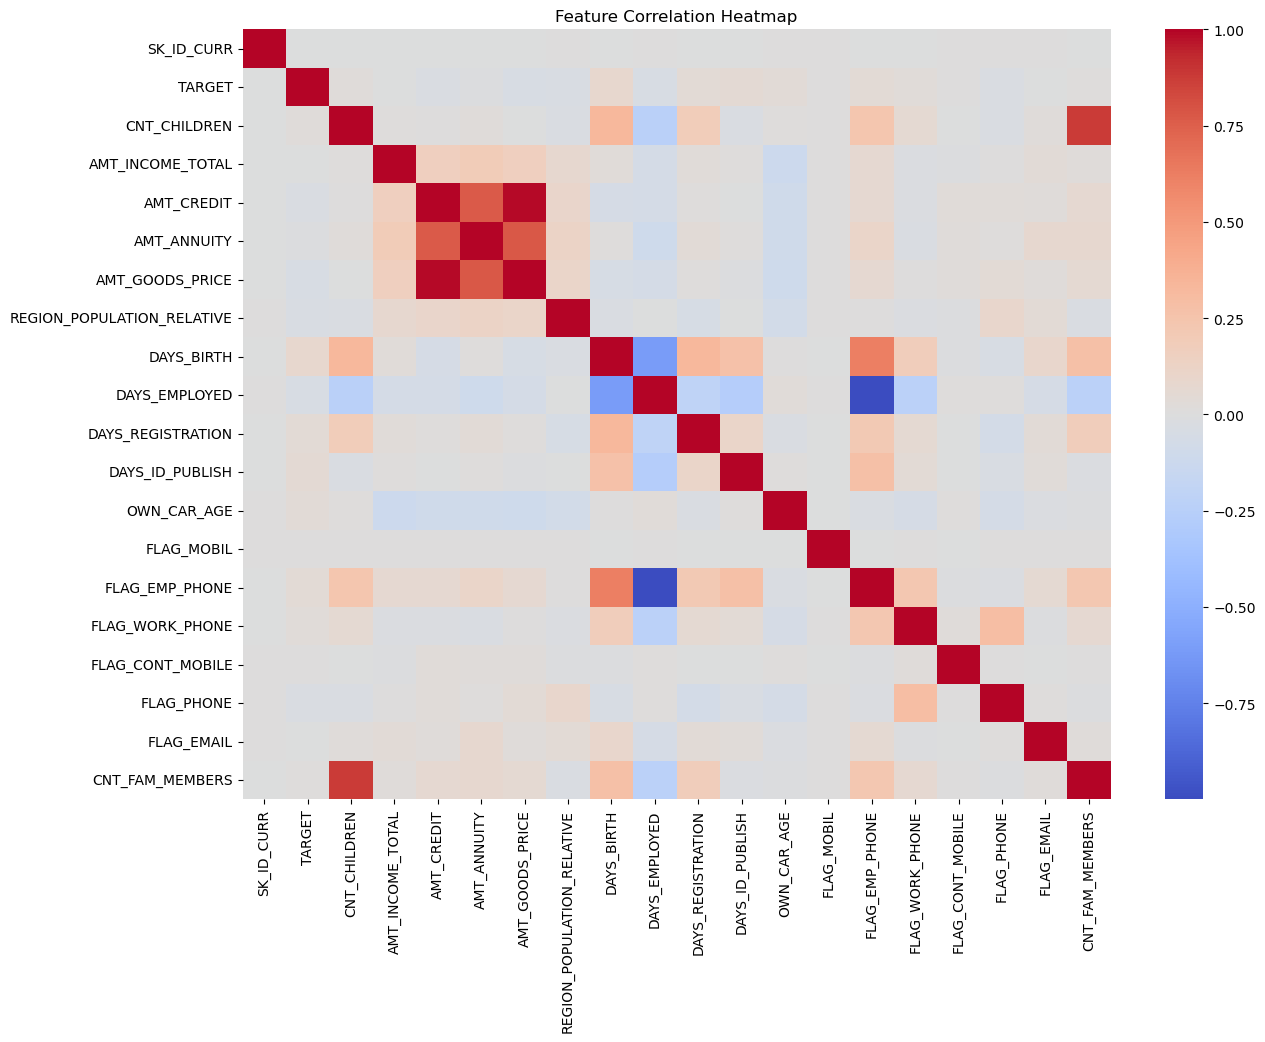

In [60]:
# Correlation Heatmap
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix.iloc[:20,:20], cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Feature Engineering

- Create a new feature `CREDIT_INCOME_RATIO` dividing `AMT_CREDIT` by `AMT_INCOME_TOTAL`.
- Create a new feature `ANNUITY_INCOME_RATIO` dividing `AMT_ANNUITY` by `AMT_INCOME_TOTAL`.
- Create a new feature `EMPLOYMENT_AGE_RATIO` dividing `DAYS_EMPLOYED` by `DAYS_BIRTH`.

In [10]:
train_df['CREDIT_INCOME_RATIO'] = train_df['AMT_CREDIT'] / train_df['AMT_INCOME_TOTAL']
train_df['ANNUITY_INCOME_RATIO'] = train_df['AMT_ANNUITY'] / train_df['AMT_INCOME_TOTAL']
train_df['EMPLOYMENT_AGE_RATIO'] = train_df['DAYS_EMPLOYED'] / train_df['DAYS_BIRTH']

<hr>
Encode categorical variables using `LabelEncoder()`

In [11]:
# Encode Categorical Variables
categorical_cols = train_df.select_dtypes(include=['object']).columns

le = LabelEncoder()

for col in categorical_cols:
    train_df[col] = train_df[col].astype(str)
    train_df[col] = le.fit_transform(train_df[col])

## Data Preparation

- Create variable `X` to hold the features and `y` to hold the target variable.
- Split data into training and test sets.
- Handle missing values (I used the `SimpleImputer()` with median imputation).
- Handle class imbalances using `SMOTE()` class.

In [20]:
# Split Features and Target
X = train_df.drop(['TARGET'], axis=1)
y = train_df['TARGET']

In [21]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
# Handle Missing values
imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

In [27]:
# Handling Class Imbalance
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

TARGET
0    226148
1     19860
Name: count, dtype: int64
TARGET
0    226148
1    226148
Name: count, dtype: int64


## Baseline Model - Logistic Regression

In [28]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_smote, y_train_smote)

log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:,1]

In [29]:
# Evaluate
print(classification_report(y_test, log_preds))

log_auc = roc_auc_score(y_test, log_probs)
print('ROC-AUC:', log_auc)

              precision    recall  f1-score   support

           0       0.94      0.60      0.73     56538
           1       0.11      0.58      0.19      4965

    accuracy                           0.59     61503
   macro avg       0.53      0.59      0.46     61503
weighted avg       0.87      0.59      0.69     61503

ROC-AUC: 0.6202766316709093


## Random Forest Model

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:,1]

In [31]:
# Evaluate Random Forest Model
rf_auc = roc_auc_score(y_test, rf_probs)
print('Random Forest ROC-AUC:', rf_auc)

Random Forest ROC-AUC: 0.6826993382557595


## XGBoost Model

In [32]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

In [33]:
# Evaluate XGBoost Model
xgb_auc = roc_auc_score(y_test, xgb_probs)
print('XGBoost ROC-AUC:', xgb_auc)

XGBoost ROC-AUC: 0.7542507179176375


## LightGBM Model

In [34]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm_model.fit(X_train_smote, y_train_smote)

lgbm_preds = lgbm_model.predict(X_test)
lgbm_probs = lgbm_model.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.169608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28232
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 121
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [36]:
# Evaluate LGBM model
lgbm_auc = roc_auc_score(y_test, lgbm_probs)
print('LightGBM ROC-AUC:', lgbm_auc)

LightGBM ROC-AUC: 0.7584105434778388


## Model Comparison (ROC AUC)

In [37]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'ROC-AUC': [log_auc, rf_auc, xgb_auc, lgbm_auc]
})

results.sort_values(by='ROC-AUC', ascending=False)

,Model,ROC-AUC
3,LightGBM,0.758411
2,XGBoost,0.754251
1,Random Forest,0.682699
0,Logistic Regression,0.620277


## Visualize Model Performance based on ROC_AUC

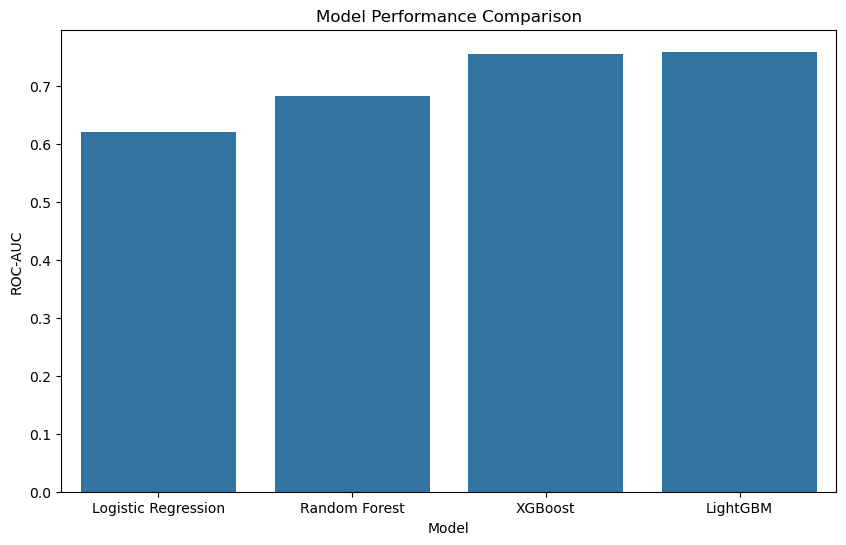

In [61]:
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='ROC-AUC', data=results)
plt.title('Model Performance Comparison');

## ROC Curve Visualization

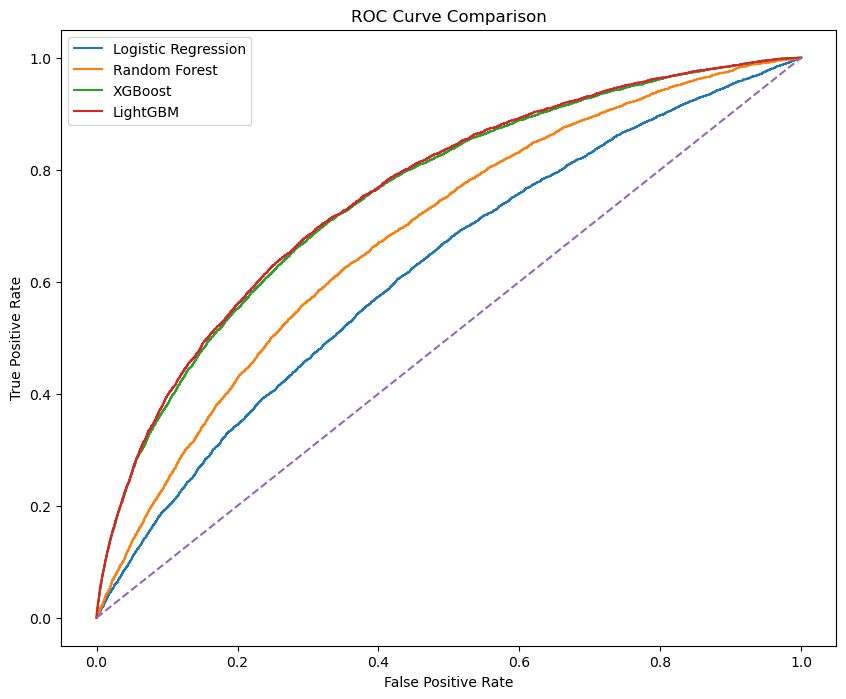

In [39]:
models = {
    'Logistic Regression': log_probs,
    'Random Forest': rf_probs,
    'XGBoost': xgb_probs,
    'LightGBM': lgbm_probs
}

plt.figure(figsize=(10,8))

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend();

## Feature Importance and Visualization

In [40]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(20)

,Feature,Importance
37,REG_CITY_NOT_WORK_CITY,0.080795
89,EMERGENCYSTATE_MODE,0.076855
25,FLAG_PHONE,0.067838
3,FLAG_OWN_CAR,0.066460
12,NAME_EDUCATION_TYPE,0.061639
96,FLAG_DOCUMENT_3,0.051810
2,CODE_GENDER,0.049467
4,FLAG_OWN_REALTY,0.045964
92,OBS_60_CNT_SOCIAL_CIRCLE,0.040142
62,ELEVATORS_MODE,0.038132


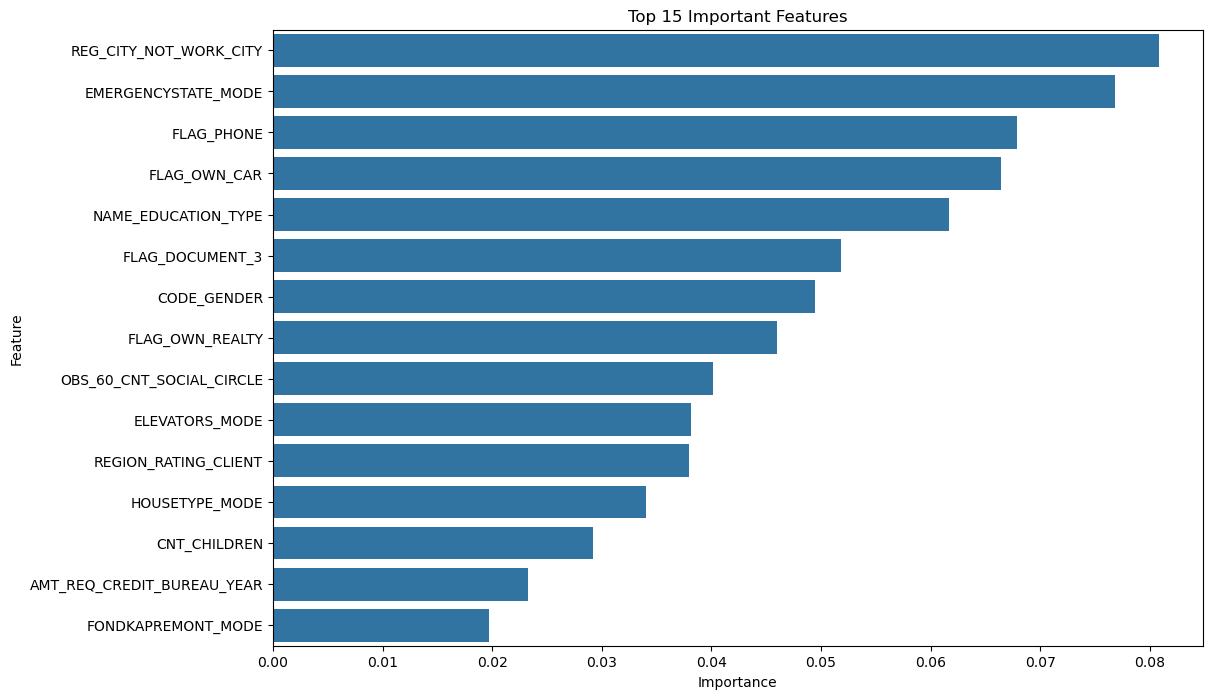

In [41]:
# Visualize Feature Importance
plt.figure(figsize=(12,8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title('Top 15 Important Features')
plt.show()

## Explainable AI Using SHAP

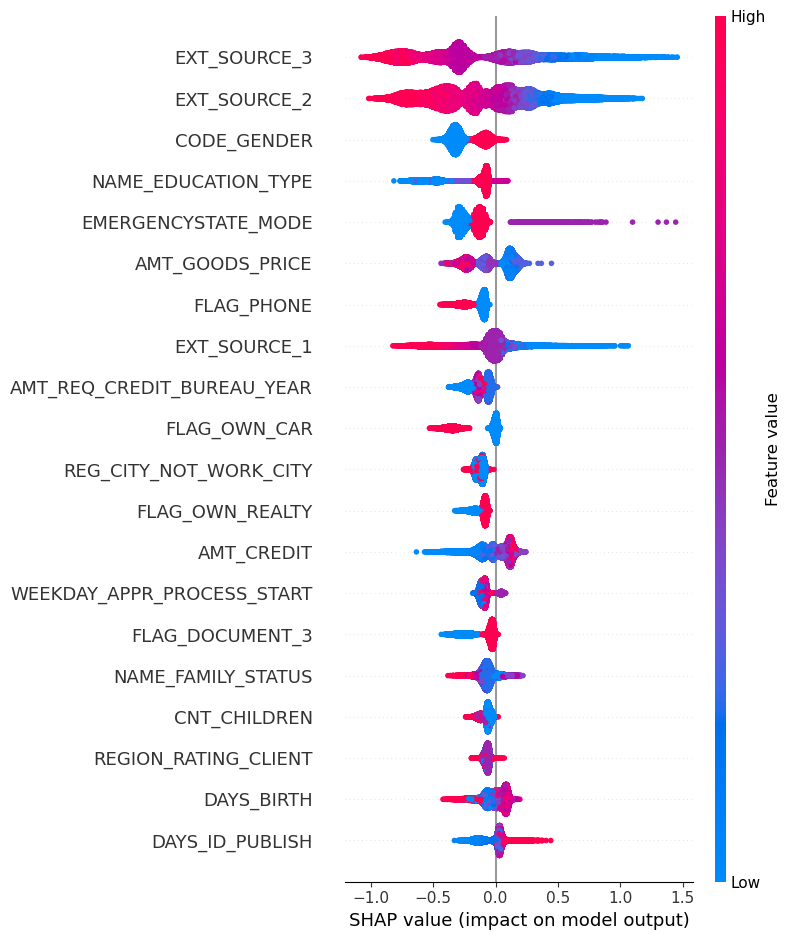

In [42]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

## Confusion Matrix

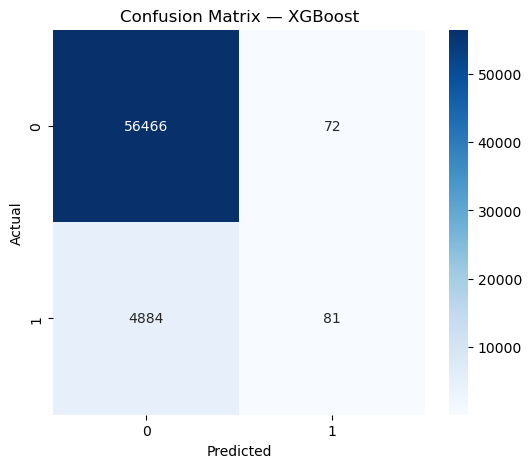

In [43]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Save Model

In [45]:
import joblib

joblib.dump(xgb_model, 'models/xgb_credit_risk_model.pkl')

['models/xgb_credit_risk_model.pkl']

## Business Interpretation

### Key Insights:

This project demonstrates how machine learning can improve credit allocation efficiency in modern financial systems. The findings suggest that advanced ensemble learning models are capable of identifying latent risk patterns beyond the capability of traditional statistical credit scoring methods. Therefore, improved risk classification contributes to:

- reduced credit losses,
- better capital allocation,
- enhanced financial sustainability, and
- improved lending inclusion for underserved populations.

The project also highlights the growing importance of Explainable AI (XAI) in financial decision-making, especially in regulated industries where model transparency is very important. Overall, the XGBoost and LightGMB perform better than the Logistic regression and Random Forest algorithms.

## Ethical Considerations

Machine learning credit systems may unintentionally introduce bias if demographic or socioeconomic proxies are learned by the algorithm. Financial institutions should therefore:

- Conduct fairness testing
- Monitor disparate impacts
- Ensure transparency
- Maintain regulatory compliance
- Incorporate human oversight